# Pronóstico semanal de concentración de NOx en Angamos 1

**Trabajo final - Series de Tiempo**  
**Equipo:** Hans Engelmann, Jessica Anaid Aguilar Mejía, Matías Nicolás García Garcete y Guillermo Eder López Rojas  
**Estado:** prototipo reproducible construido desde la entrega final hacia el análisis.

Este notebook contiene la ruta completa exigida por la pauta: contexto, preparación de datos, análisis exploratorio, comparación temporal, diagnóstico, prueba final y pronóstico con intervalos.

## 1. Problema y objetivo

La fuente es el sistema SNIFA de la Superintendencia del Medio Ambiente. Se estudian registros horarios reportados para la central `ANGAMOS`, unidad `ANGAMOS 1`, y la variable continua `CONCENTRACION_NOX_MG_NM3`.

**Objetivo general:** modelar y pronosticar la concentración semanal media reportada y medida (`DM`) de NOx de Angamos 1, considerando todos los estados operacionales, comparando modelos de series de tiempo con criterios explícitos y generando un pronóstico de ocho semanas con intervalos predictivos del 95%.

La magnitud analizada es una **concentración en mg/Nm³**; no corresponde a masa total emitida ni debe expresarse en toneladas.

## 2. Diseño previo del análisis

- Periodo disponible localmente: 1 de enero de 2020 a 30 de septiembre de 2025.
- Frecuencia original: horaria.
- Frecuencia analítica: semanal, con cierre en domingo.
- Regla de calidad: dato NOx medido (`TIPO_DATO_NOX` comienza por `DM`) y semana con al menos 75% de 168 horas.
- Vacíos: interpolación temporal limitada a un máximo de dos semanas consecutivas.
- Validación: 32 semanas.
- Prueba final: últimas 8 semanas, utilizadas una sola vez.
- Horizonte final: 8 semanas.

Las transformaciones, imputaciones y modelos se ajustan sin utilizar información de la prueba final para seleccionar el modelo.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from statsmodels.tsa.stattools import adfuller

ROOT = Path.cwd().resolve()
if ROOT.name == "prototipo_entrega":
    PROTO = ROOT
    PROJECT_ROOT = ROOT.parent
else:
    PROJECT_ROOT = ROOT
    PROTO = ROOT / "prototipo_entrega"

DATA = PROTO / "data"
TABLES = PROTO / "resultados" / "tablas"
FIGURES = PROTO / "resultados" / "figuras"

H_VALIDACION = 32
H_PRUEBA = 8
H_PRONOSTICO = 8
PERIODO_ESTACIONAL = 52

## 3. Auditoría y construcción de la base

La siguiente celda vuelve a leer los 23 CSV por bloques, filtra Angamos 1 y genera las bases reducidas. Su ejecución tarda aproximadamente uno o dos minutos y evita cargar cerca de 3 GB simultáneamente.

Para una revisión rápida puede omitirse, porque los resultados ya fueron exportados en `prototipo_entrega/data/` y `prototipo_entrega/resultados/tablas/`.

In [2]:
# Descomentar para reconstruir la base desde los CSV originales.
# %run ../ejecutar_auditoria.py

In [3]:
resumen_auditoria = json.loads(
    (TABLES / "resumen_auditoria.json").read_text(encoding="utf-8")
)
cobertura_anual = pd.read_csv(TABLES / "01_cobertura_anual.csv")
tipo_dato = pd.read_csv(TABLES / "03_tipo_dato_nox.csv")
estado_uge = pd.read_csv(TABLES / "04_estado_uge.csv")

display(pd.Series(resumen_auditoria, name="resultado"))
display(cobertura_anual)
display(tipo_dato)
display(estado_uge)

archivos                                           23
periodo_archivos                     [2020-1, 2025-3]
registros_angamos                               50400
fechas_invalidas                                    0
duplicados_fecha_hora                               0
valores_nox_numericos                           50400
mediciones_validas                              48574
semanas_totales                                   301
semanas_modelamiento                              289
porcentaje_semanas_utilizables                  96.01
fecha_min                         2020-01-01 00:00:00
fecha_max                         2025-09-30 23:00:00
Name: resultado, dtype: object

,anio,registros,horas_unicas,valores_nox,mediciones_validas,fecha_inicio,fecha_fin
0,2020,8784,8784,8784,8514,2020-01-01,2020-12-31 23:00:00
1,2021,8760,8760,8760,8284,2021-01-01,2021-12-31 23:00:00
2,2022,8760,8760,8760,8396,2022-01-01,2022-12-31 23:00:00
3,2023,8760,8760,8760,8398,2023-01-01,2023-12-31 23:00:00
4,2024,8784,8784,8784,8651,2024-01-01,2024-12-31 23:00:00
5,2025,6552,6552,6552,6331,2025-01-01,2025-09-30 23:00:00


,tipo_dato_nox,n,porcentaje
0,DM,48574,96.376984
1,DS,1826,3.623016


,estado_uge,n,porcentaje
0,RE,47208,93.666667
1,HE,1310,2.599206
2,FA,1081,2.144841
3,DP,394,0.781746
4,DNP,241,0.478175
5,HA,166,0.329365


### Resultado de la auditoría

Se encontraron 50.400 observaciones horarias continuas, ninguna fecha inválida y ningún duplicado fecha-hora. El 96,38% de los registros corresponde a códigos de medición (`DM`), mientras que 3,62% corresponde a datos sustituidos (`DS`).

La cobertura permite continuar: 289 de las 301 semanas inicialmente formadas superaron simultáneamente las reglas de cobertura y borde. Para mantener un índice semanal regular se excluyeron las dos semanas parciales de los extremos y se interpolaron diez semanas interiores con cobertura inferior al 75%; los vacíos fueron aislados o de un máximo de dos semanas.

In [4]:
semanal = pd.read_csv(
    DATA / "angamos1_nox_semanal_modelo.csv",
    parse_dates=["semana_fin"]
).set_index("semana_fin")

assert semanal.index.is_monotonic_increasing
assert semanal.index.to_series().diff().dropna().eq(pd.Timedelta(days=7)).all()
assert semanal["nox_modelo_mg_nm3"].notna().all()

print("Semanas:", len(semanal))
print("Semanas imputadas:", int(semanal["valor_imputado"].sum()))
display(semanal.head())

Semanas: 299
Semanas imputadas: 10


,horas_validas,nox_media_mg_nm3,nox_mediana_mg_nm3,nox_sd_mg_nm3,nox_min_mg_nm3,nox_max_mg_nm3,horas_esperadas,cobertura,semana_utilizable,semana_completa_en_periodo,usar_modelamiento,valor_observado_mg_nm3,valor_imputado,nox_modelo_mg_nm3
semana_fin,,,,,,,,,,,,,,
2020-01-12,164,313.305945,306.957001,33.236959,259.351013,419.552002,168,0.976190,True,True,True,313.305945,False,313.305945
2020-01-19,161,309.019093,303.806000,28.570807,270.040009,408.355988,168,0.958333,True,True,True,309.019093,False,309.019093
2020-01-26,148,356.078129,358.057495,37.991371,294.877991,428.488007,168,0.880952,True,True,True,356.078129,False,356.078129
2020-02-02,166,334.356626,330.459000,26.729993,283.459991,406.763000,168,0.988095,True,True,True,334.356626,False,334.356626
2020-02-09,167,325.446917,325.773987,58.817038,233.460999,561.830017,168,0.994048,True,True,True,325.446917,False,325.446917


## 4. Análisis exploratorio

Se revisan nivel, variabilidad, posibles cambios estructurales, estacionalidad anual y autocorrelación. Las figuras se guardan separadamente para poder reutilizarlas en el informe ejecutivo.

> **Advertencia de interpretación:** los valores corresponden a concentración de NOx en los gases de chimenea de la unidad Angamos 1, corregida por oxígeno y expresada en base seca. No representan la concentración de NOx en el aire ambiente ni la exposición de la población de Mejillones.

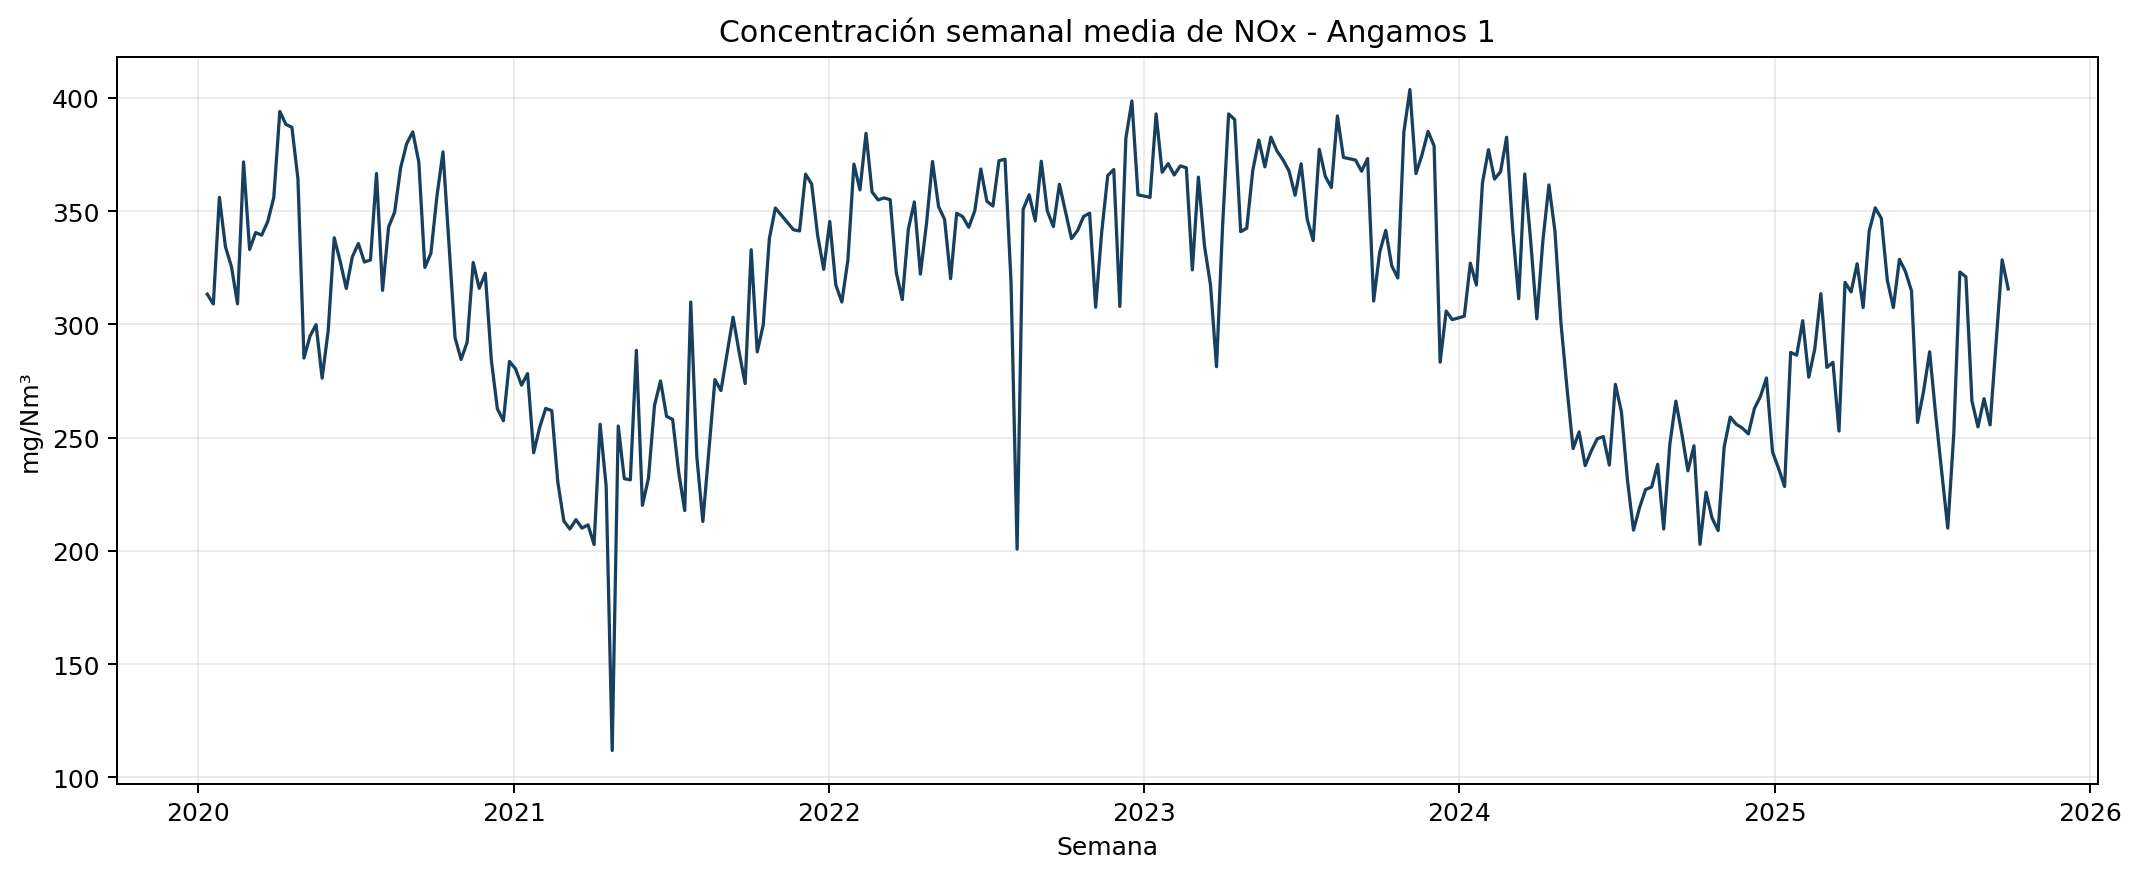

,NOx mg/Nm³
count,299.000000
mean,312.240101
std,52.683122
min,111.902796
25%,270.662898
50%,323.124400
75%,355.442415
max,403.672503


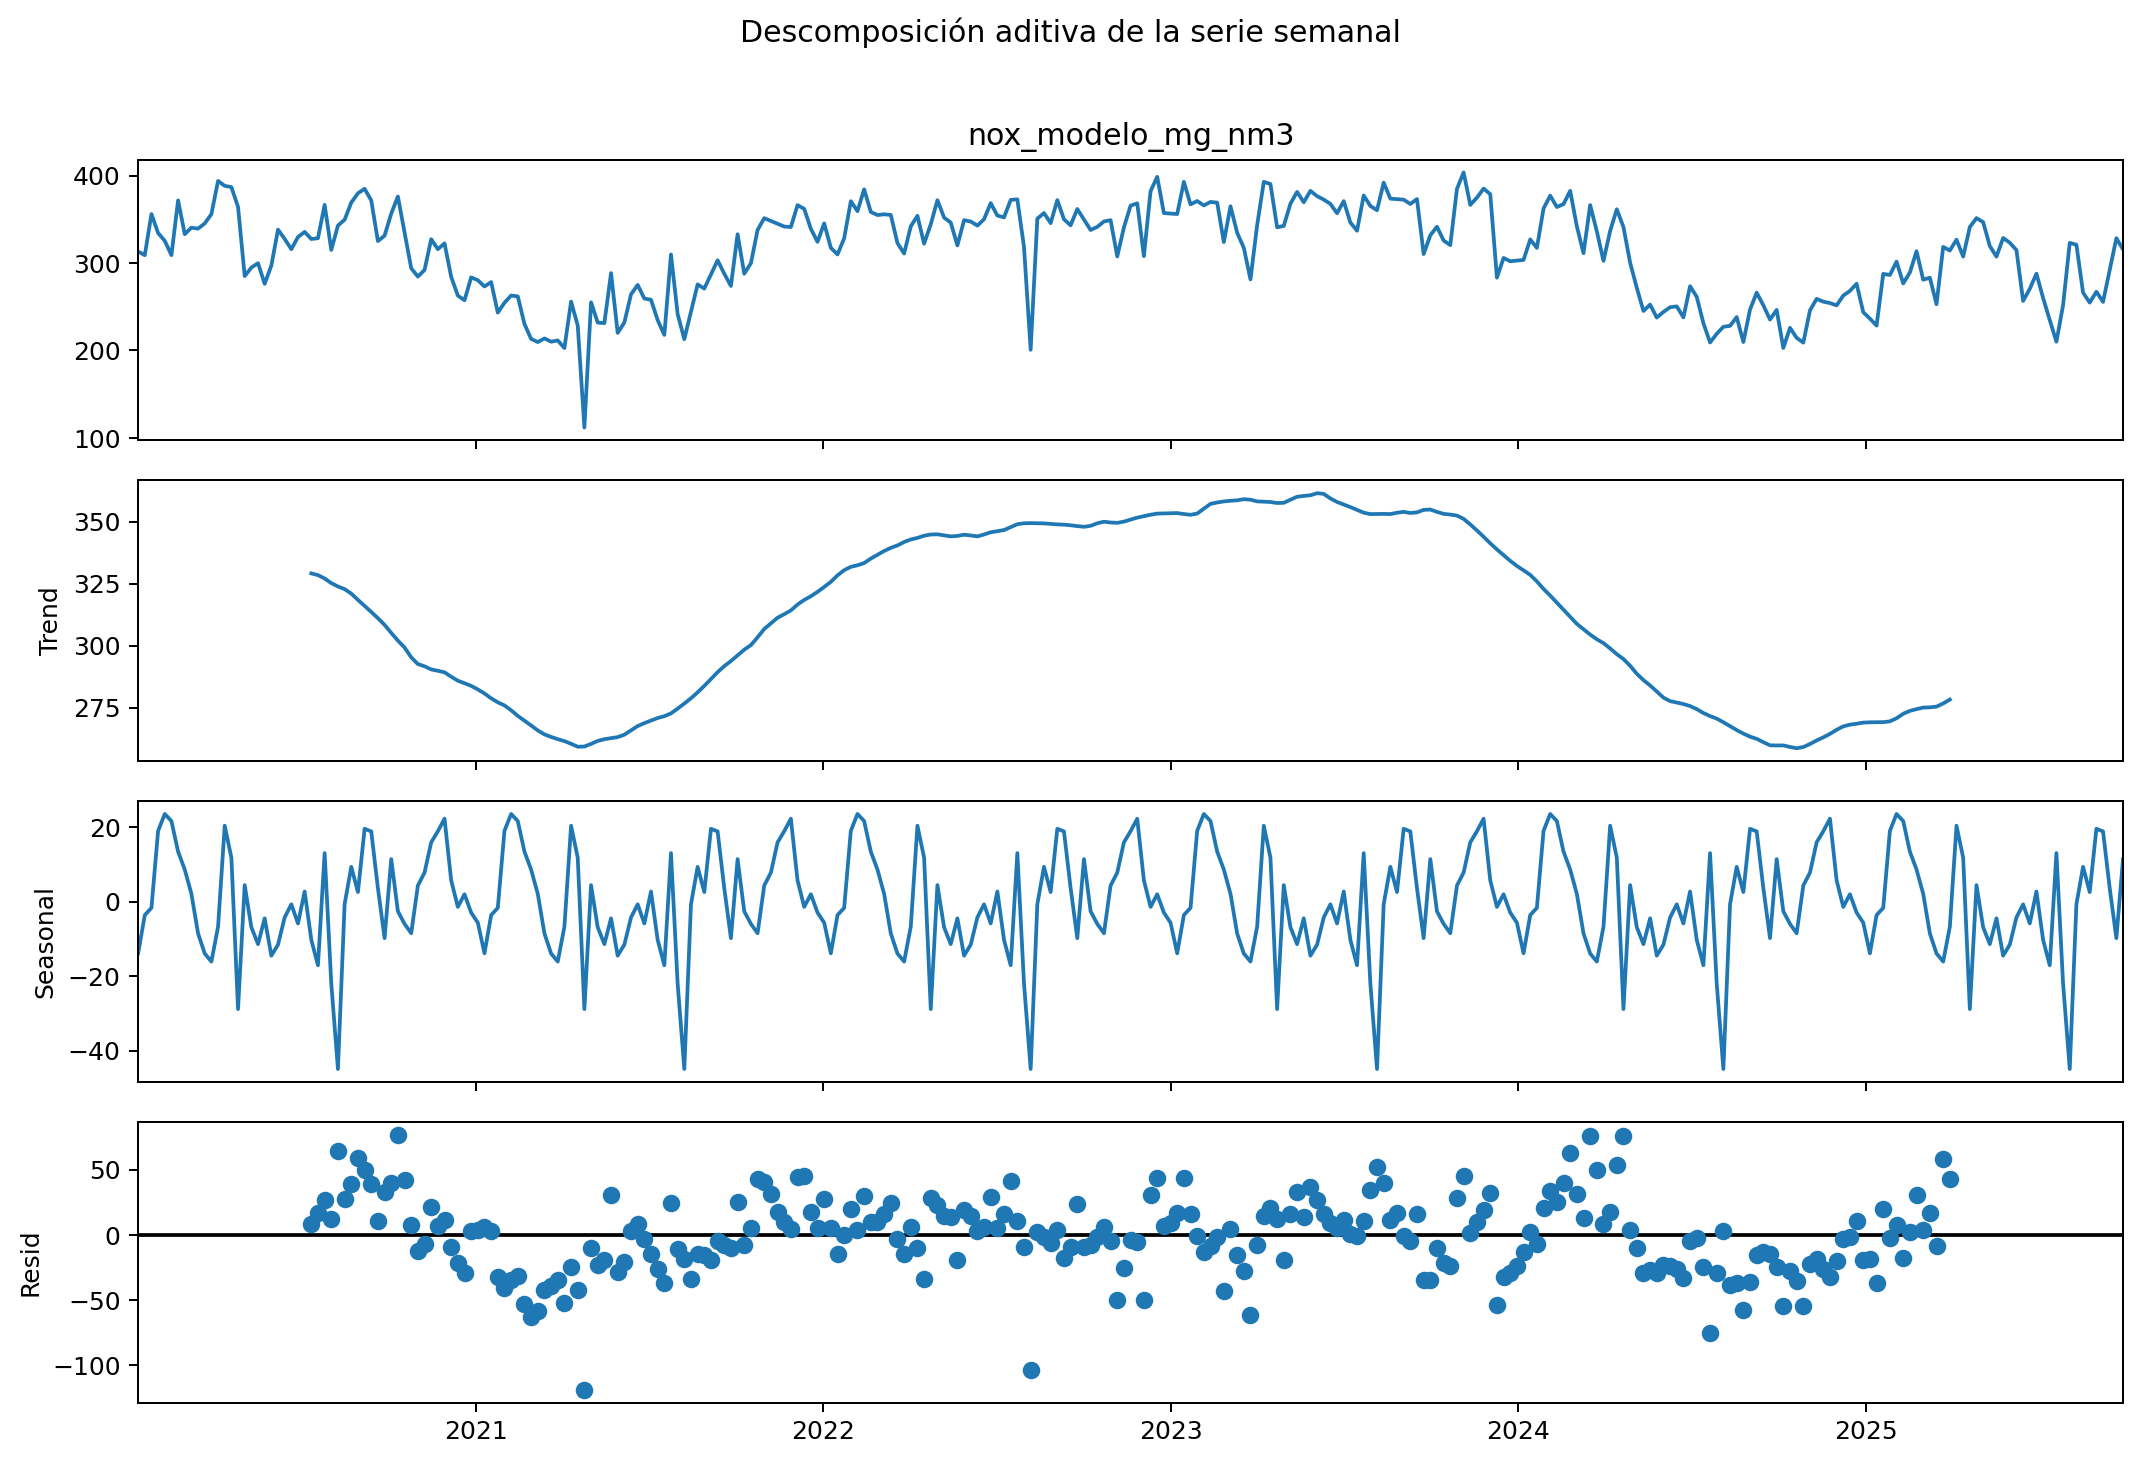

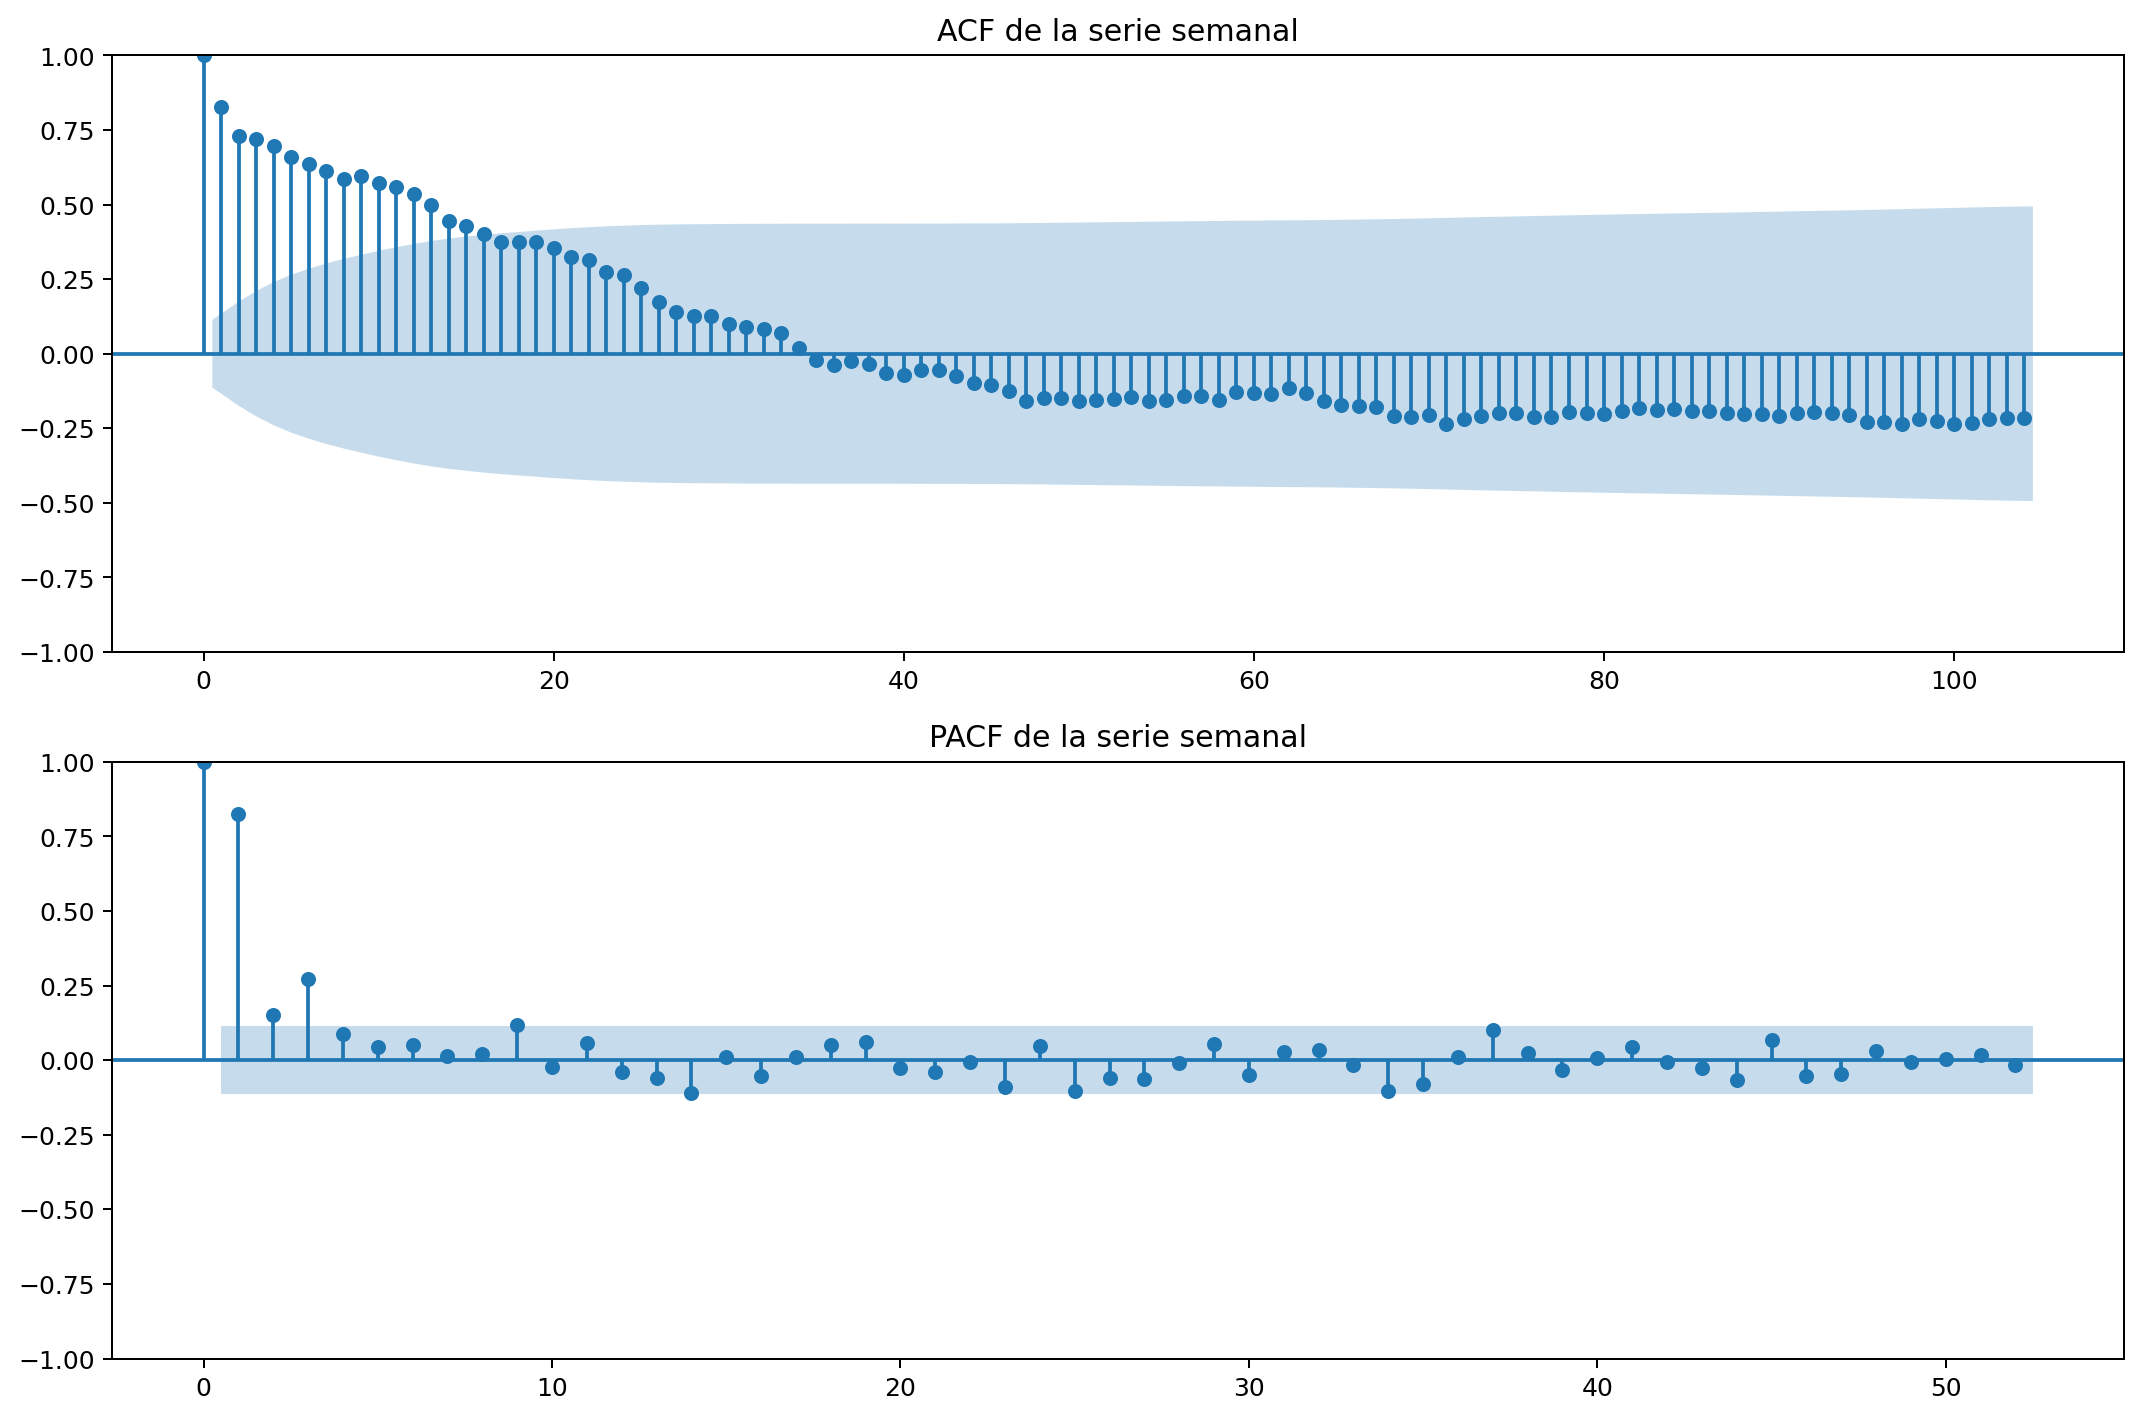

In [5]:
display(Image(filename=str(FIGURES / "01_serie_historica.png")))
display(semanal["nox_modelo_mg_nm3"].describe().to_frame("NOx mg/Nm³"))
display(Image(filename=str(FIGURES / "02_descomposicion.png")))
display(Image(filename=str(FIGURES / "03_acf_pacf.png")))

### Interpretación exploratoria

La serie fluctúa alrededor de 312,24 mg/Nm³, con una desviación estándar semanal de 52,68 mg/Nm³. Se observan cambios de nivel y episodios de mayor volatilidad, pero no una tendencia monotónica persistente. La ACF y la PACF muestran dependencia temporal principalmente de corto plazo. El rezago 52 no presenta un aporte claro, por lo que no se impondrá una estructura autorregresiva anual.

La descomposición es una herramienta descriptiva: no demuestra por sí sola que exista estacionalidad estable ni que los residuos sean ruido blanco.

In [6]:
serie = semanal["nox_modelo_mg_nm3"].astype(float)
adf_nivel = adfuller(serie)
adf_diferencia = adfuller(serie.diff().dropna())
pd.DataFrame({
    "serie": ["Nivel", "Primera diferencia"],
    "estadístico ADF": [adf_nivel[0], adf_diferencia[0]],
    "p-value": [adf_nivel[1], adf_diferencia[1]],
    "n observaciones": [adf_nivel[3], adf_diferencia[3]]
})

,serie,estadístico ADF,p-value,n observaciones
0,Nivel,-2.851612,5.127119e-02,295
1,Primera diferencia,-14.102762,2.601135e-26,295


El ADF en nivel entrega un valor p cercano a 0,051: al 5% no se rechaza la raíz unitaria, aunque el resultado es limítrofe. En primera diferencia el valor p es prácticamente cero. Siguiendo el material del curso, se comparan candidatos ARIMA con `d=0` y `d=1`; la validación temporal y el diagnóstico residual determinan cuál representa mejor la serie.

## 5. Partición temporal

La selección usa solamente entrenamiento y validación. La prueba final permanece intacta hasta haber escogido el modelo.

In [7]:
train = serie.iloc[:-(H_VALIDACION + H_PRUEBA)]
validacion = serie.iloc[-(H_VALIDACION + H_PRUEBA):-H_PRUEBA]
prueba = serie.iloc[-H_PRUEBA:]

pd.DataFrame({
    "conjunto": ["Entrenamiento", "Validación", "Prueba final"],
    "n": [len(train), len(validacion), len(prueba)],
    "inicio": [train.index.min(), validacion.index.min(), prueba.index.min()],
    "fin": [train.index.max(), validacion.index.max(), prueba.index.max()],
})

,conjunto,n,inicio,fin
0,Entrenamiento,259,2020-01-12,2024-12-22
1,Validación,32,2024-12-29,2025-08-03
2,Prueba final,8,2025-08-10,2025-09-28


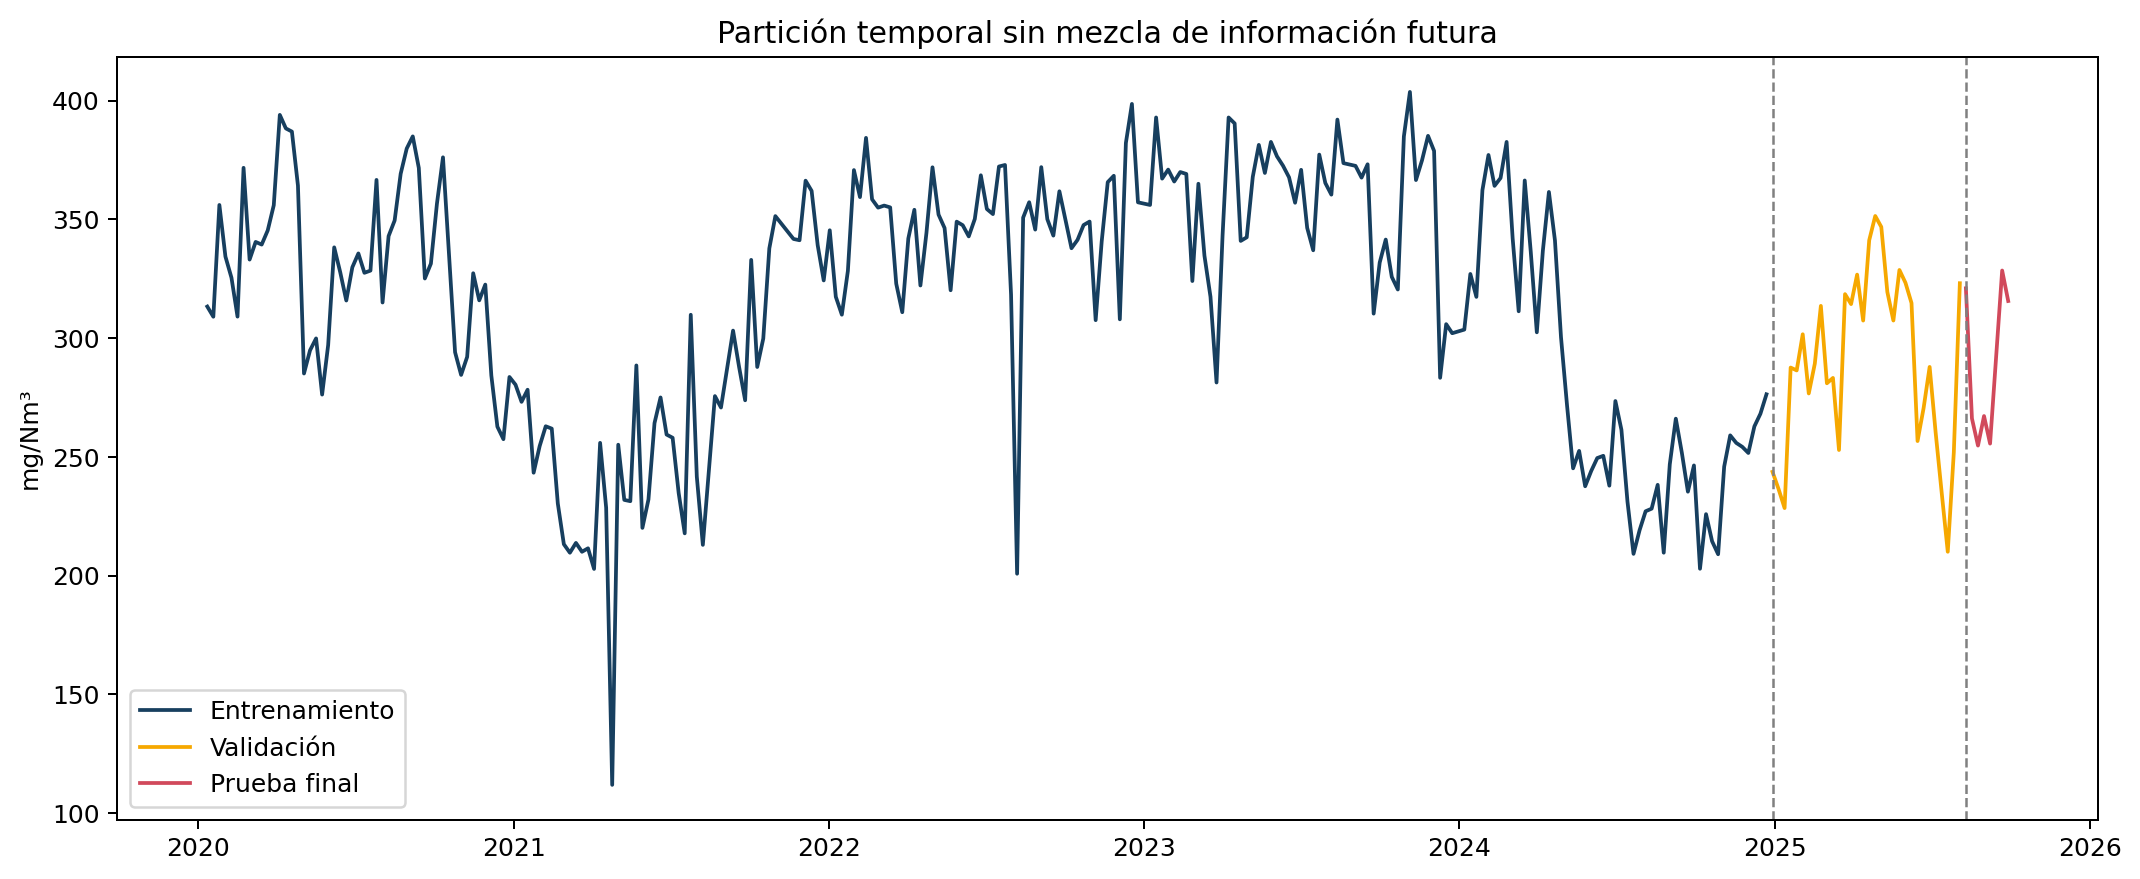

In [8]:
display(Image(filename=str(FIGURES / "04_particion_temporal.png")))

## 6. Modelos y criterio de selección

Se comparan:

1. ingenuo de último valor;
2. ingenuo estacional de 52 semanas;
3. drift;
4. suavizamiento exponencial simple;
5. Holt amortiguado;
6. ETS aditivo con periodo 52, como comparación estacional;
7. ARIMA(1,0,0) y ARIMA(3,0,0), propuestos desde la PACF en nivel;
8. ARIMA(1,1,0), ARIMA(2,1,0), ARIMA(0,1,1) y ARIMA(0,1,2), propuestos desde el ADF y la ACF/PACF de la primera diferencia.

**Regla previa:** exigir `Ljung-Box p > 0,05` en residuos de entrenamiento y, entre los modelos que cumplan, escoger el menor RMSE de validación. El AIC se informa solo como apoyo dentro de modelos probabilísticos; no se usa para comparar directamente familias diferentes.

In [9]:
# Descomentar para recalcular todos los modelos y actualizar las salidas.
# %run ../ejecutar_modelado_final.py

comparacion = pd.read_csv(TABLES / "07_comparacion_validacion.csv")
display(comparacion.style.format({
    "RMSE": "{:.2f}", "MAE": "{:.2f}", "MAPE": "{:.2f}",
    "sMAPE": "{:.2f}", "AIC": "{:.2f}", "Ljung_Box_p_10": "{:.4f}"
}))

,modelo,RMSE,MAE,MAPE,sMAPE,AIC,Ljung_Box_p_10,ranking_RMSE
0,"ARIMA(3,0,0)",35.99,29.24,10.80,10.23,2444.29,0.5288,1
1,Ingenuo último valor,38.93,33.40,11.51,11.71,nan,0.0000,2
2,"ARIMA(1,0,0)",39.10,29.49,11.35,10.33,2492.59,0.2263,3
3,"ARIMA(1,1,0)",39.52,34.01,11.66,11.93,2487.54,0.2665,4
4,Drift,39.91,34.09,11.65,11.96,nan,0.0000,5
5,"ARIMA(2,1,0)",40.63,35.00,11.90,12.29,2447.51,0.8505,6
6,"ARIMA(0,1,1)",41.89,36.11,12.19,12.70,2455.43,0.8038,7
7,SES,41.93,36.15,12.20,12.71,1748.37,0.0768,8
8,Holt amortiguado,42.35,36.46,12.28,12.83,1754.36,0.0779,9
9,"ARIMA(0,1,2)",45.28,38.92,12.97,13.75,2435.02,0.9740,10


**ARIMA(3,0,0)** obtuvo el menor RMSE de validación (35,99 mg/Nm³) y sus residuos superaron Ljung-Box (`p = 0,529`). El ingenuo de último valor quedó segundo, pero conservó autocorrelación (`p < 0,001`). De acuerdo con la regla declarada previamente, se seleccionó ARIMA(3,0,0). El AIC se interpreta solamente entre los modelos ARIMA comparables.

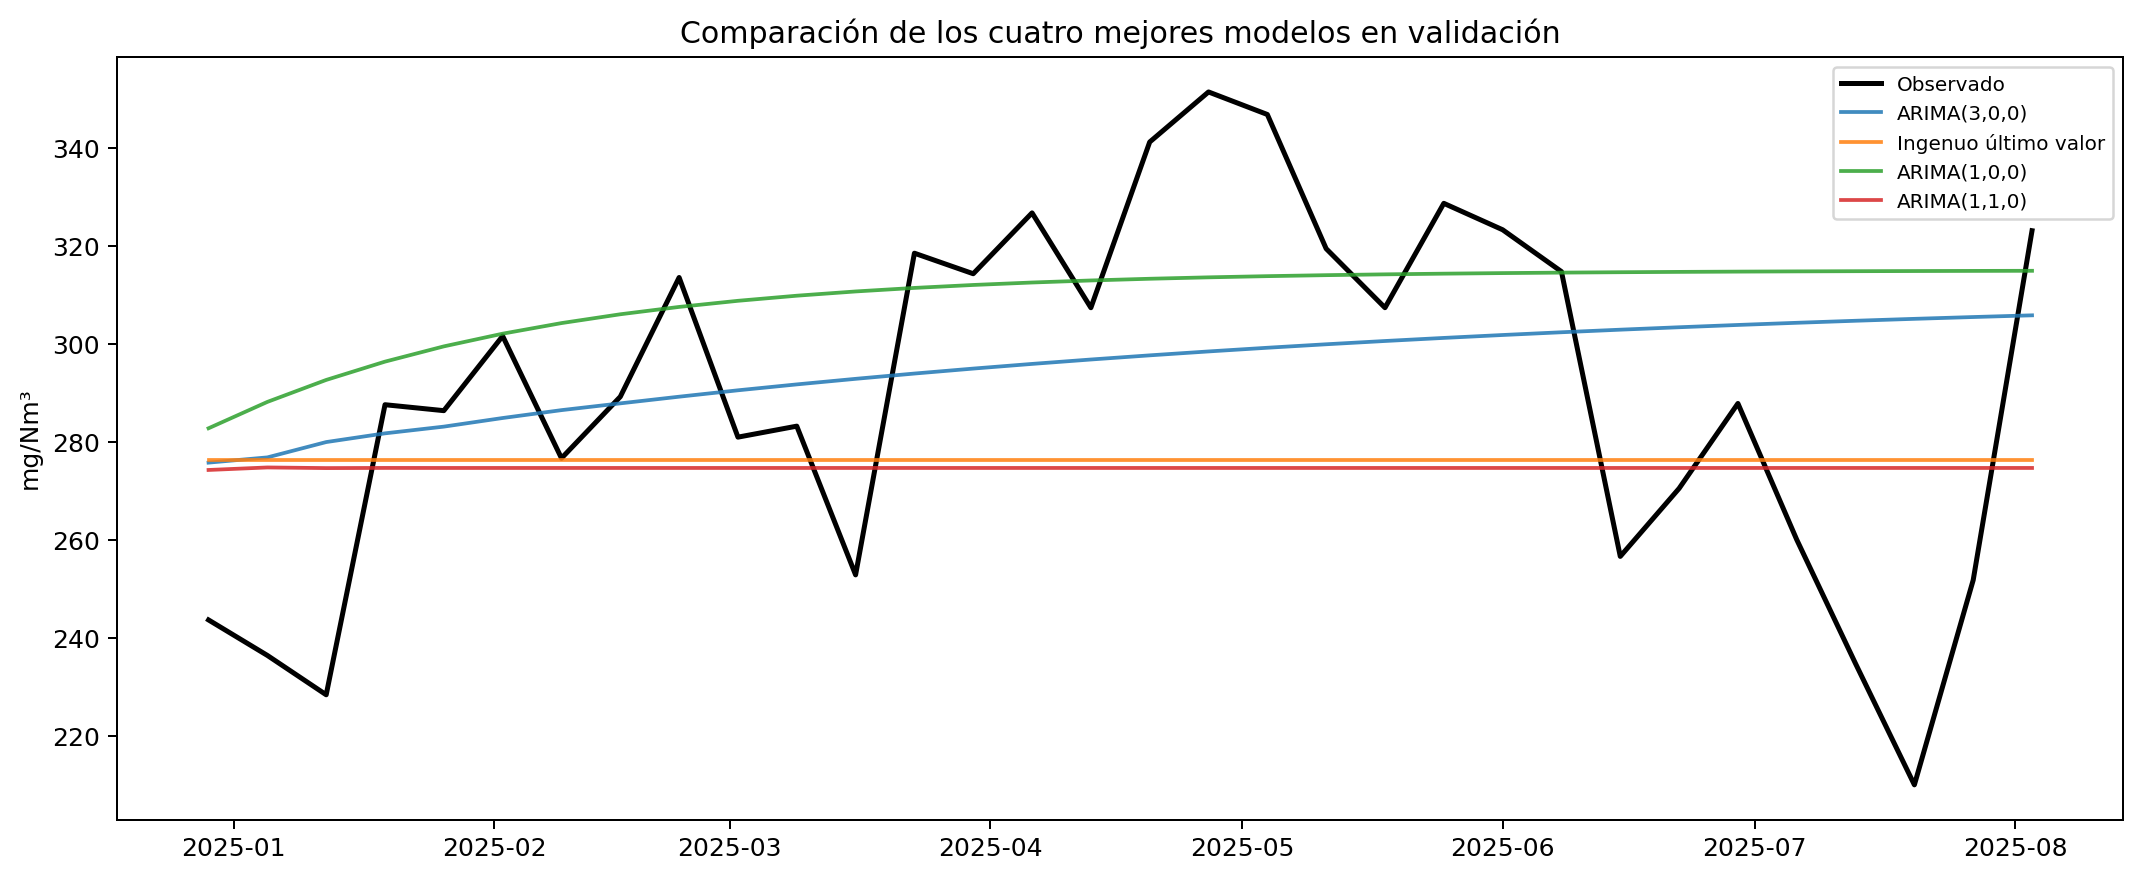

,modelo,semanas_bloque_prueba,semanas_observadas_evaluadas,RMSE,MAE,MAPE,sMAPE
0,"ARIMA(3,0,0)",8,7,30.233987,28.890217,10.315222,10.025562


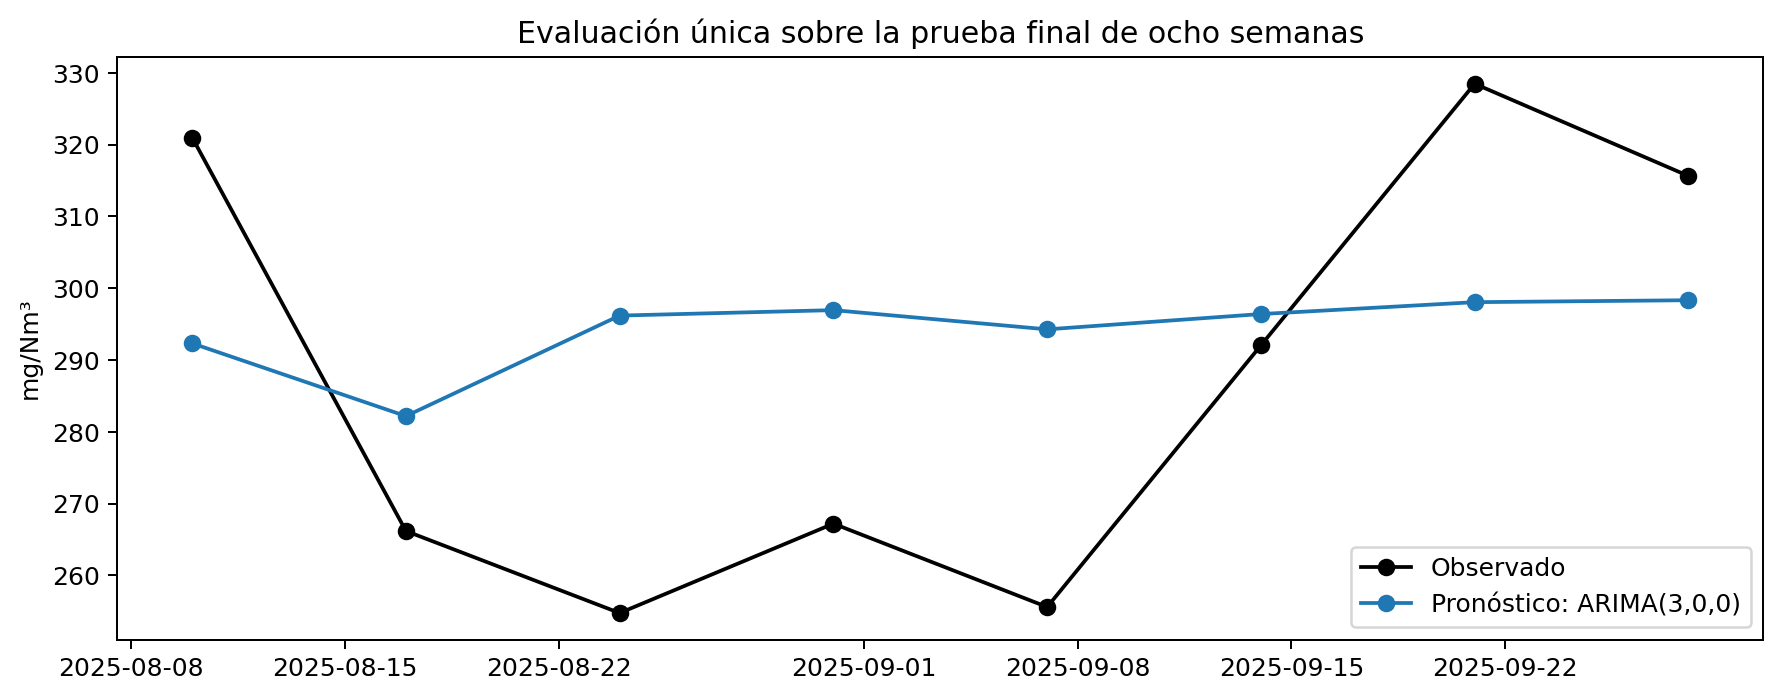

In [10]:
display(Image(filename=str(FIGURES / "05_validacion_modelos.png")))
metricas_prueba = pd.read_csv(TABLES / "08_metricas_prueba_final.csv")
display(metricas_prueba)
display(Image(filename=str(FIGURES / "06_prueba_final.png")))

## 7. Evaluación final y diagnóstico

El bloque final conserva ocho semanas cronológicas, pero una carecía de cobertura suficiente y había sido interpolada. Para no evaluar el modelo contra un valor construido, las métricas se calcularon sobre las siete semanas observadas: RMSE 30,23 mg/Nm³, MAE 28,89 mg/Nm³, MAPE 10,32% y sMAPE 10,03%. Estos resultados no se utilizaron para cambiar el modelo.

Tras reentrenar ARIMA(3,0,0) con las 299 semanas, Ljung-Box entregó valores p de 0,572 en el rezago 10 y 0,308 en el rezago 20. No se rechaza la hipótesis de ausencia de autocorrelación residual, por lo que el modelo final se considera apropiado respecto de la blancura.

,lag,lb_stat,lb_pvalue
0,10,8.579963,0.572375
1,20,22.614109,0.308137


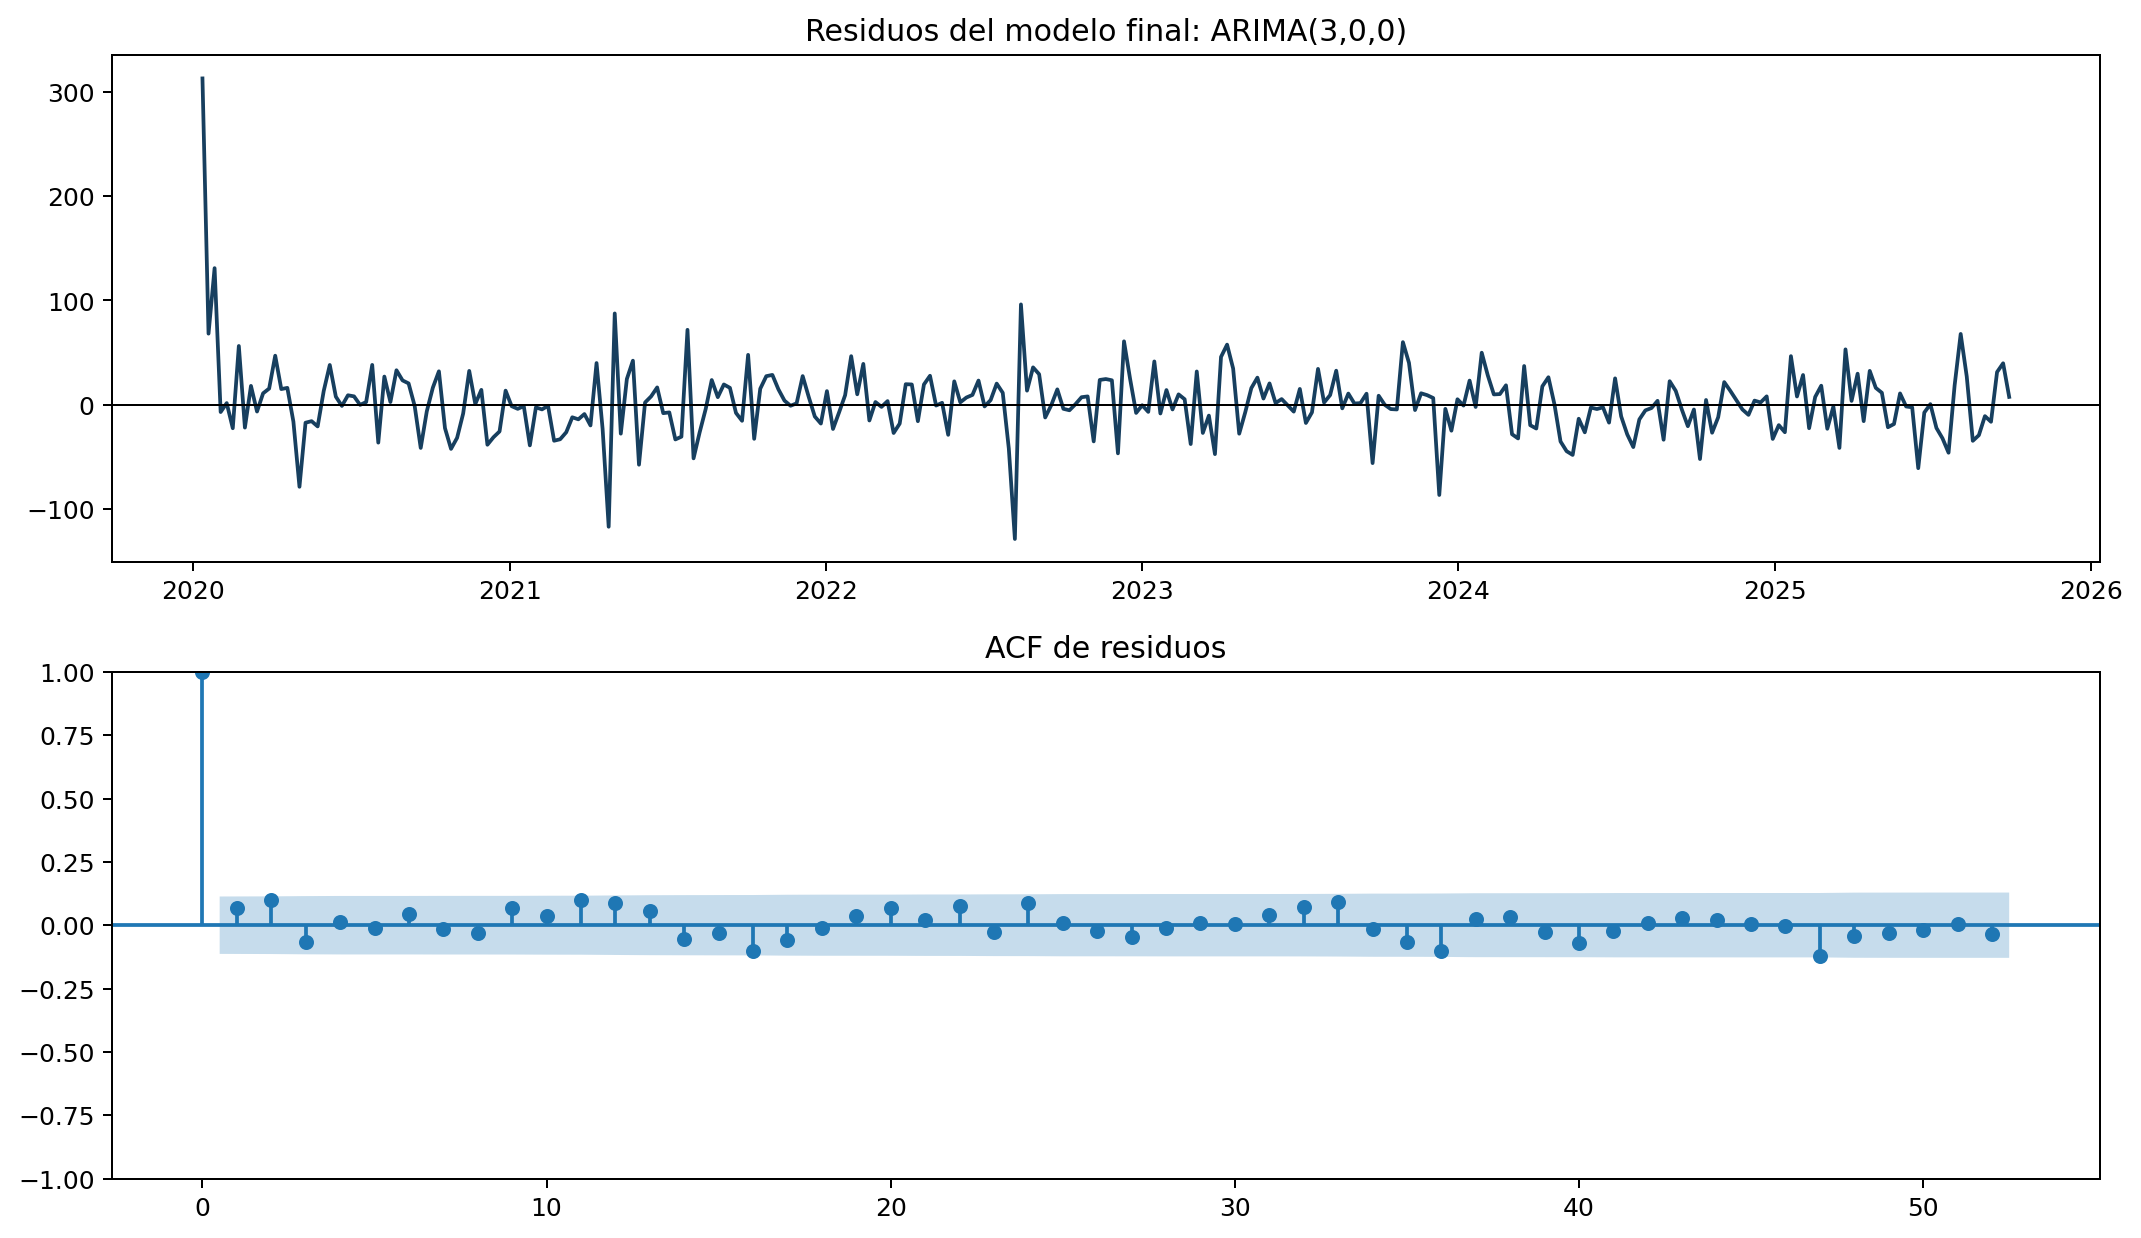

In [11]:
ljung = pd.read_csv(TABLES / "10_ljung_box_modelo_final.csv")
display(ljung)
display(Image(filename=str(FIGURES / "08_diagnostico_residuos.png")))

## 8. Pronóstico de ocho semanas

El modelo se reentrena con toda la serie y se proyectan ocho semanas. Los intervalos predictivos del 95% aumentan con el horizonte, reflejando la incertidumbre acumulada.

,semana_fin,pronostico_nox_mg_nm3,limite_inferior_95,limite_superior_95,modelo,metodo_intervalo
0,2025-10-05,308.182602,252.895769,363.469435,"ARIMA(3,0,0)","Intervalo predictivo del modelo ARIMA, 95%"
1,2025-10-12,313.684933,247.376202,379.993664,"ARIMA(3,0,0)","Intervalo predictivo del modelo ARIMA, 95%"
2,2025-10-19,314.147333,244.301226,383.993440,"ARIMA(3,0,0)","Intervalo predictivo del modelo ARIMA, 95%"
3,2025-10-26,312.198538,236.933528,387.463549,"ARIMA(3,0,0)","Intervalo predictivo del modelo ARIMA, 95%"
4,2025-11-02,312.384717,232.215548,392.553886,"ARIMA(3,0,0)","Intervalo predictivo del modelo ARIMA, 95%"
5,2025-11-09,312.714597,229.288231,396.140962,"ARIMA(3,0,0)","Intervalo predictivo del modelo ARIMA, 95%"
6,2025-11-16,312.395528,226.177462,398.613594,"ARIMA(3,0,0)","Intervalo predictivo del modelo ARIMA, 95%"
7,2025-11-23,312.221171,223.492537,400.949804,"ARIMA(3,0,0)","Intervalo predictivo del modelo ARIMA, 95%"


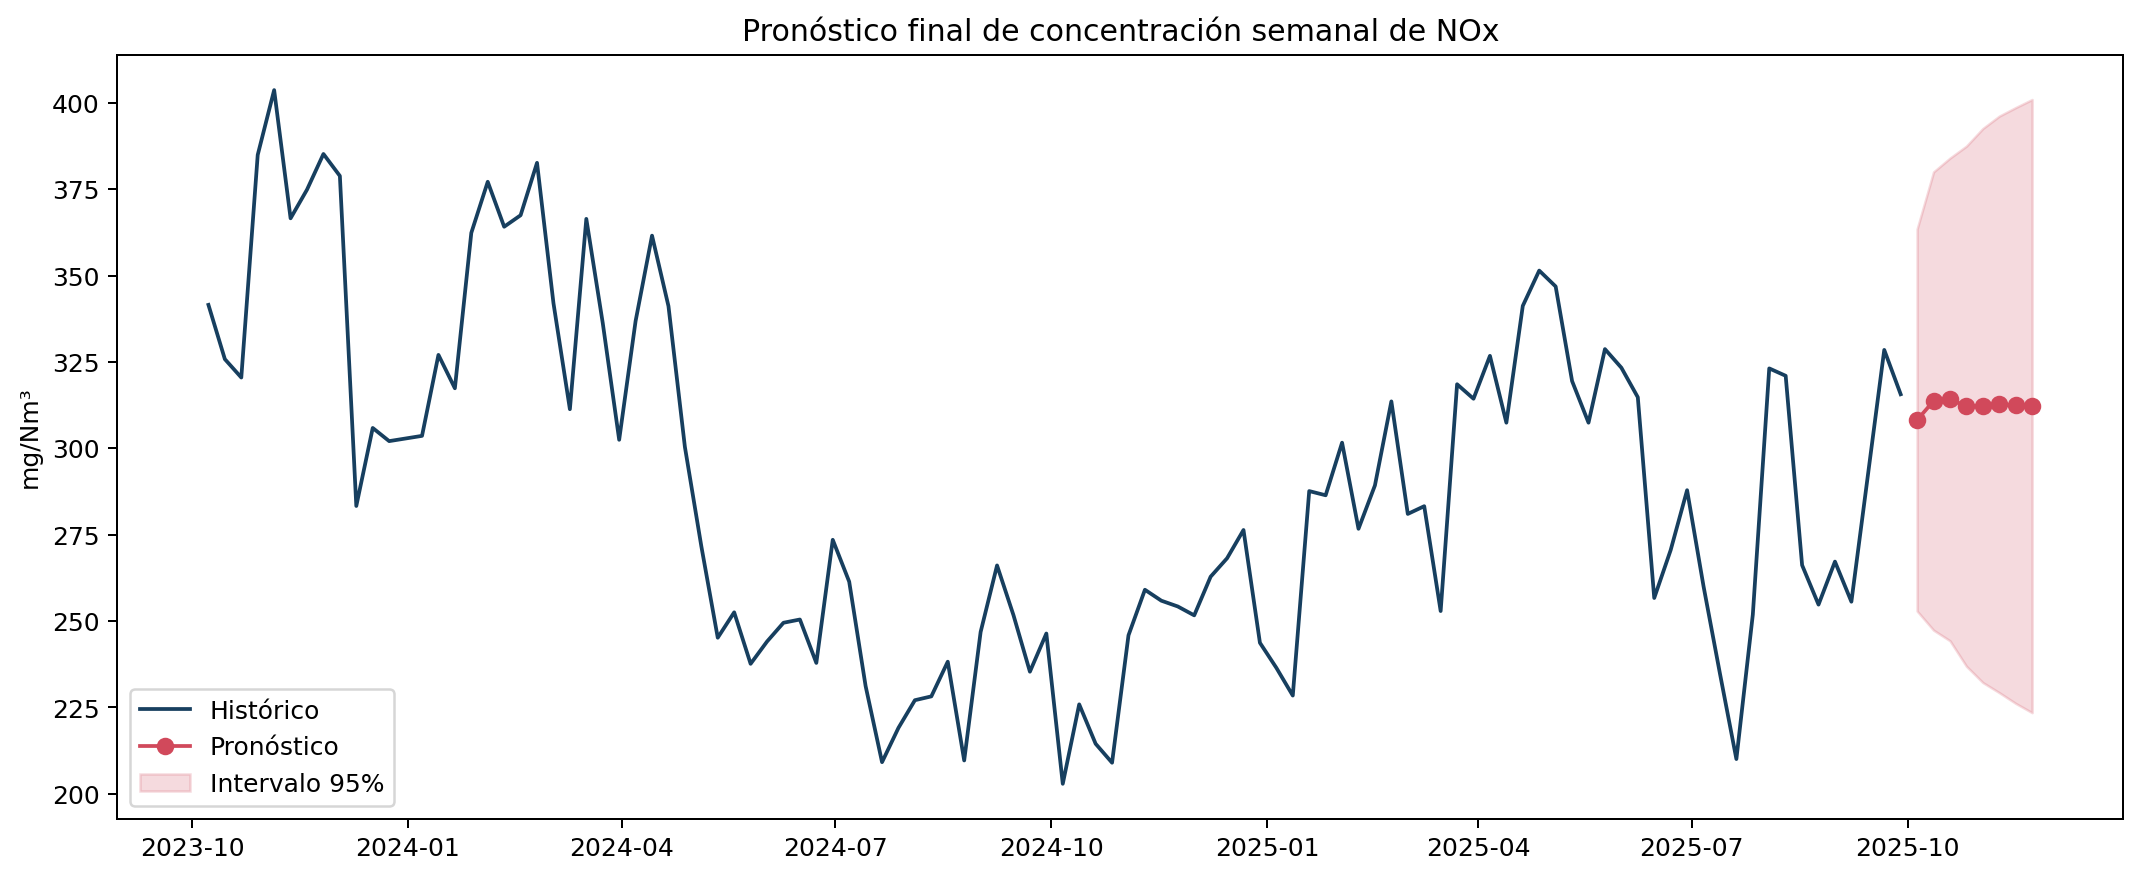

In [12]:
pronostico = pd.read_csv(
    TABLES / "09_pronostico_final_8_semanas.csv",
    parse_dates=["semana_fin"]
)
display(pronostico)
display(Image(filename=str(FIGURES / "07_pronostico_final.png")))

## 8.1 Análisis de sensibilidad

Se mantuvo el modelo ARIMA(3,0,0) y se modificó la construcción de la serie: umbral 50%, ausencia de umbral, mediana semanal y restricción a mediciones en estado `RE`. Esto permite separar la estabilidad del modelo de las decisiones de limpieza.

,escenario,semanas_imputadas,correlacion_con_base,validacion_RMSE,validacion_MAE,validacion_sMAPE,prueba_RMSE,prueba_MAE,prueba_sMAPE,prueba_semanas_observadas,ljung_p_10,ljung_p_20,pronostico_medio_8s,pronostico_min_8s,pronostico_max_8s
0,"Media, cobertura 75%",10,1.000,35.99,29.243177,10.233801,30.23,28.89,10.025562,7,0.572,0.308,312.24,308.182602,314.147333
1,"Media, cobertura 50%",1,0.950,36.20,28.689426,10.046076,29.97,28.14,9.735626,8,0.699,0.507,315.36,314.098429,317.938243
2,"Media, sin umbral",0,0.950,36.20,28.690898,10.046574,29.97,28.14,9.735527,8,0.698,0.505,315.35,314.094641,317.938248
3,"Mediana, cobertura 75%",10,0.975,43.42,35.757644,13.000087,35.08,31.86,12.392232,7,0.761,0.599,301.67,299.788359,302.717499
4,"Media DM+RE, cobertura 75%",25,0.966,35.44,28.827651,10.085234,25.78,24.10,8.390391,7,0.142,0.099,305.19,299.234411,306.663800


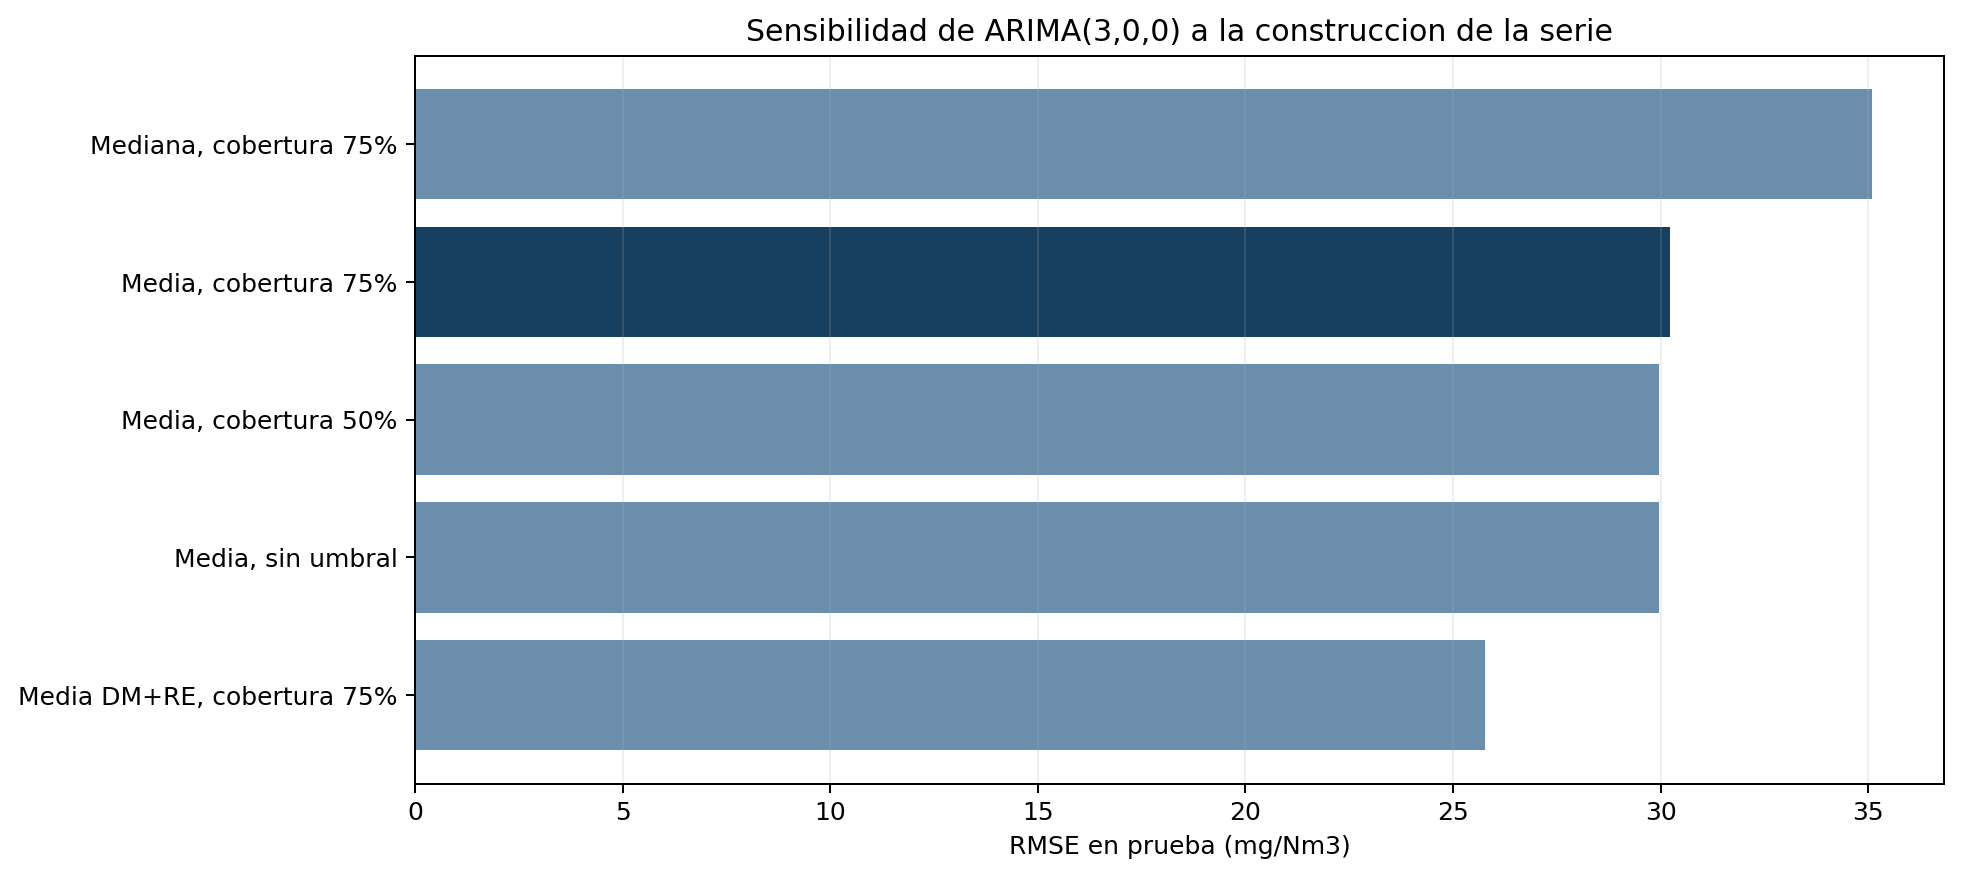

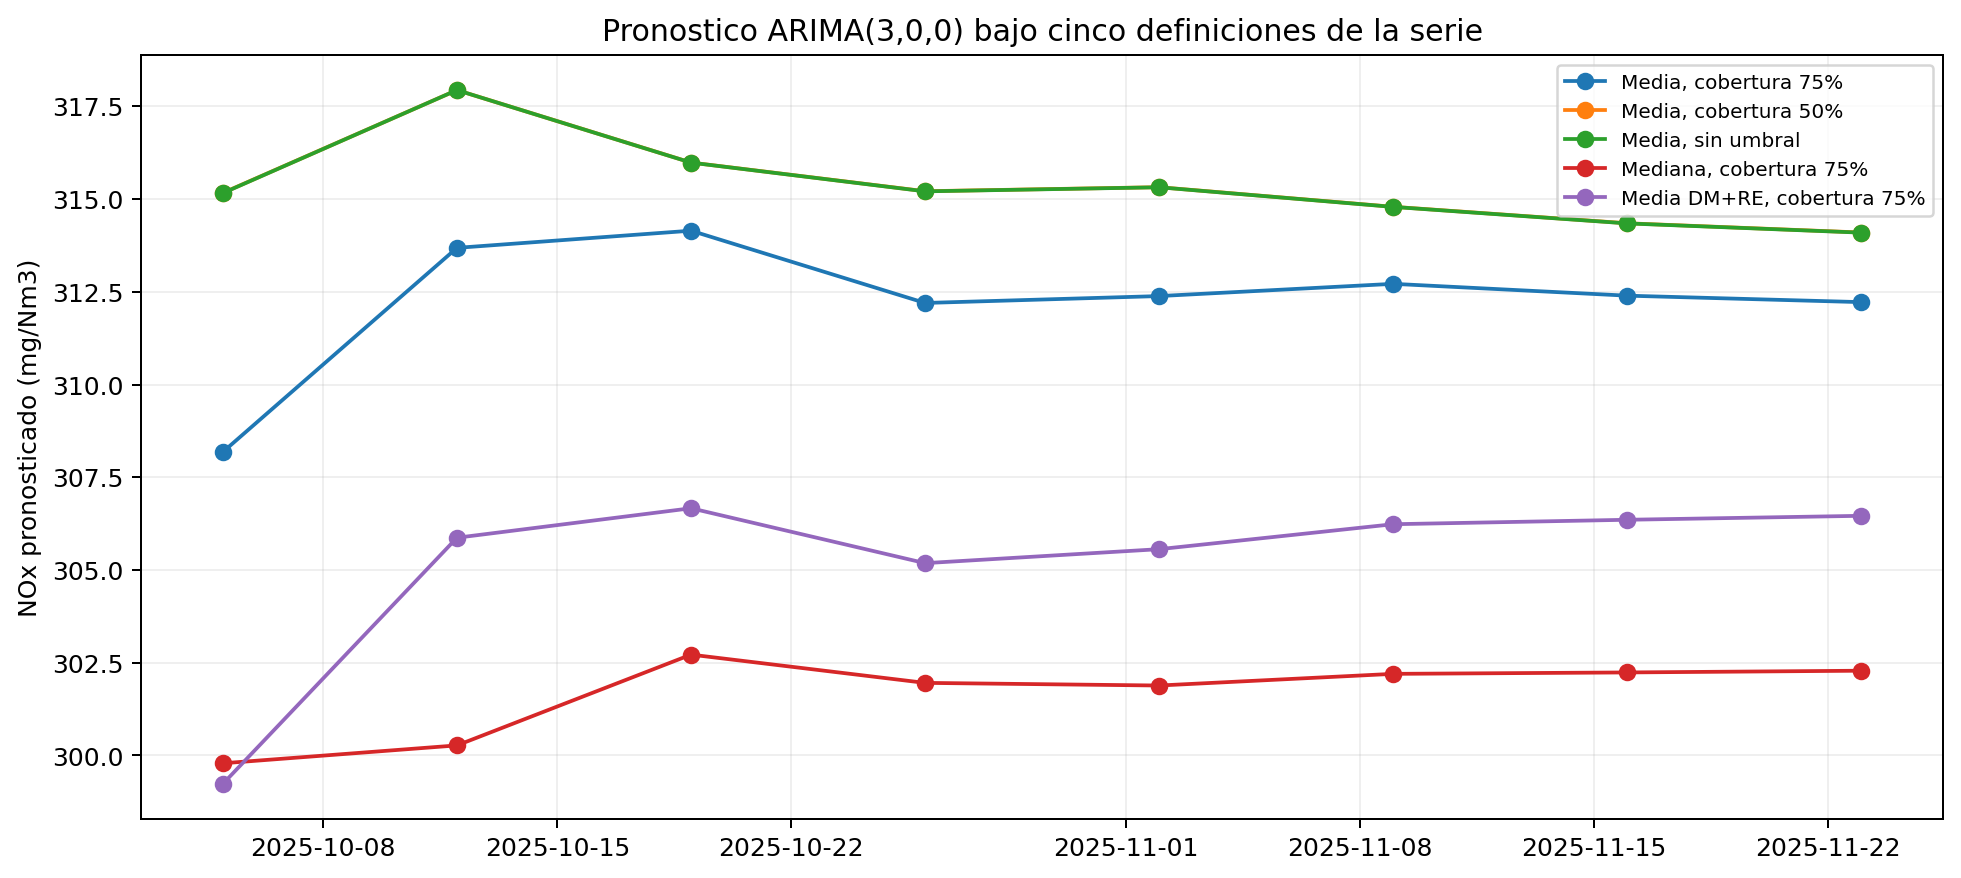

In [13]:
sensibilidad = pd.read_csv(TABLES / "12_analisis_sensibilidad.csv")
display(sensibilidad.style.format({
    "correlacion_con_base": "{:.3f}",
    "validacion_RMSE": "{:.2f}", "prueba_RMSE": "{:.2f}",
    "prueba_MAE": "{:.2f}", "ljung_p_10": "{:.3f}",
    "ljung_p_20": "{:.3f}", "pronostico_medio_8s": "{:.2f}"
}))
display(Image(filename=str(FIGURES / "09_sensibilidad_construccion_serie.png")))
display(Image(filename=str(FIGURES / "10_sensibilidad_pronostico.png")))

ARIMA(3,0,0) mantuvo residuos compatibles con ruido blanco en los cinco escenarios (`p > 0,05`). Los escenarios de media con cobertura 50% y sin umbral fueron prácticamente idénticos y elevaron el pronóstico medio desde 312,24 hasta aproximadamente 315,35 mg/Nm³. La mediana redujo el nivel esperado a 301,67 mg/Nm³ y `DM+RE` a 305,19 mg/Nm³.

Se conserva la media de datos medidos con cobertura 75% porque corresponde al objetivo definido antes del modelado. El escenario `DM+RE`, aunque obtuvo menor error en este bloque, responde a otra pregunta: concentración durante operación en régimen; por ello no reemplaza la especificación principal.

## 9. Conclusiones y limitaciones

- La serie disponible es utilizable y presenta alta cobertura desde 2020 hasta septiembre de 2025.
- Un modelo sencillo de último valor pronostica razonablemente, pero no elimina la dependencia temporal.
- ARIMA(3,0,0), propuesto a partir de la PACF y evaluado mediante validación temporal, ofrece el menor RMSE y residuos compatibles con ruido blanco.
- El nivel central esperado para las ocho semanas siguientes se mantiene aproximadamente entre 308 y 314 mg/Nm³.
- Los intervalos son amplios; las predicciones deben interpretarse como concentración media semanal, no como masa emitida ni como evaluación de cumplimiento normativo.
- La SMA señala que los datos son reportados por los regulados y no necesariamente han sido procesados o verificados por la institución.

- Los códigos se contrastaron con la Resolución Exenta SMA N.º 404/2017: `DM` es dato medido, `DS` dato sustituido y `RE` operación en régimen. También se documentaron `HE`, `HA`, `FA`, `DP` y `DNP` en `CODIGOS_OFICIALES.md`.
- La diferencia del escenario `DM+RE` muestra que mezclar estados operacionales es una limitación sustantiva; el pronóstico principal no debe interpretarse como concentración exclusiva durante régimen.

**Pendiente antes de entregar:** revisar redacción, nombres de integrantes y formato final del documento Word.

## 10. Archivos de entrega

- Notebook: `Trabajo_Final_Series_Tiempo.ipynb`.
- Base horaria filtrada: `data/angamos1_nox_horaria_filtrada.csv`.
- Base semanal utilizada: `data/angamos1_nox_semanal_modelo.csv`.
- Informe ejecutivo: `INFORME_EJECUTIVO.md`.
- Tablas y figuras reproducibles: `resultados/`.

Conversión sugerida a Word:

```bash
pandoc INFORME_EJECUTIVO.md -o INFORME_EJECUTIVO.docx --resource-path=.
```